# 감정 각성도 예측 — EDA (Exploratory Data Analysis)

**센서:** Empatica E4 (ACC, BVP, EDA, HR, IBI, TEMP) + NeuroSky Mindwave (Brain)  
**목표:** arousal 1–5 분류 / 평가 지표: Balanced Accuracy (target ≥ 0.3)

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# ── 경로 설정 ──────────────────────────────────────────
DATA_DIR = './'   # CSV 파일이 있는 폴더로 변경하세요

SENSORS = ['acc', 'brain', 'bvp', 'eda', 'hr', 'ibi', 'temp']
PIDS = ['01Z2','70N8','7PF3','CQ2G','D1XP','DT5C','F1ZM','LIUY','SE4Q','TPQI','Y21H']
AROUSAL_COLORS = {1:'#4575b4', 2:'#91bfdb', 3:'#fee090', 4:'#fc8d59', 5:'#d73027'}

print('Libraries loaded.')

Libraries loaded.


## 1. 데이터 로드

In [2]:
# 레이블
train_label = pd.read_csv(f'{DATA_DIR}train-label.csv')
test_label  = pd.read_csv(f'{DATA_DIR}test-label.csv')

# 센서 데이터
train = {}
test  = {}
for s in SENSORS:
    train[s] = pd.read_csv(f'{DATA_DIR}train-{s}.csv')
    test[s]  = pd.read_csv(f'{DATA_DIR}test-{s}.csv')
    train[s]['timestamp'] = pd.to_numeric(train[s]['timestamp'])
    test[s]['timestamp']  = pd.to_numeric(test[s]['timestamp'])

train_label['timestamp'] = pd.to_numeric(train_label['timestamp'])
test_label['timestamp']  = pd.to_numeric(test_label['timestamp'])

# 기본 정보
print(f'Train labels : {train_label.shape}  |  PIDs: {sorted(train_label.pid.unique())}')
print(f'Test  labels : {test_label.shape}')
print()
for s in SENSORS:
    print(f'  train-{s:6s}: {str(train[s].shape):18s}  cols={list(train[s].columns)}')

Train labels : (1456, 4)  |  PIDs: ['01Z2', '70N8', '7PF3', 'CQ2G', 'D1XP', 'DT5C', 'F1ZM', 'LIUY', 'SE4Q', 'TPQI', 'Y21H']
Test  labels : (1496, 4)

  train-acc   : (419930, 5)         cols=['pid', 'timestamp', 'x', 'y', 'z']
  train-brain : (12337, 10)         cols=['pid', 'timestamp', 'delta', 'lowAlpha', 'highAlpha', 'lowBeta', 'highBeta', 'lowGamma', 'middleGamma', 'theta']
  train-bvp   : (839848, 3)         cols=['pid', 'timestamp', 'value']
  train-eda   : (52498, 3)          cols=['pid', 'timestamp', 'value']
  train-hr    : (13019, 3)          cols=['pid', 'timestamp', 'value']
  train-ibi   : (8234, 3)           cols=['pid', 'timestamp', 'value']
  train-temp  : (52490, 3)          cols=['pid', 'timestamp', 'value']


## 2. 레이블 분석

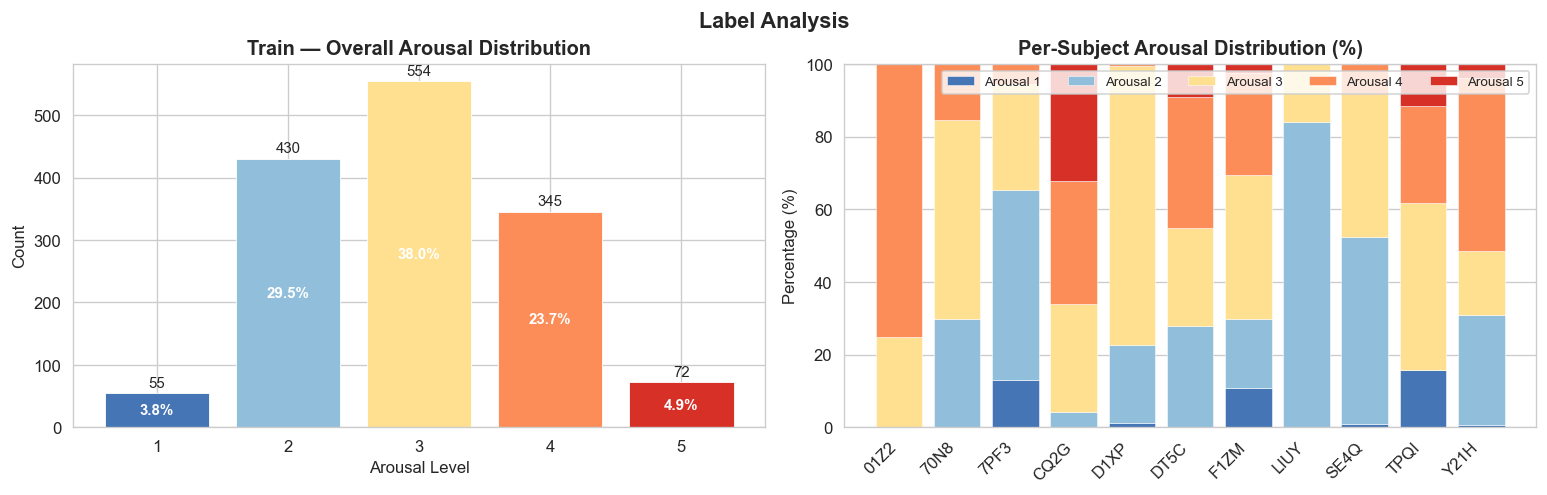

=== Class Balance (Train) ===
  Arousal 1:   55 (  3.8%)  █████
  Arousal 2:  430 ( 29.5%)  ███████████████████████████████████████████
  Arousal 3:  554 ( 38.0%)  ███████████████████████████████████████████████████████
  Arousal 4:  345 ( 23.7%)  ██████████████████████████████████
  Arousal 5:   72 (  4.9%)  ███████

  ⚠ Imbalance ratio (max/min): 10.1x
  ⚠ Class 1 & 5 are rare → Balanced Accuracy metric is crucial


In [3]:
# ── 2-1. 전체 클래스 분포 ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 전체 분포
counts = train_label['arousal'].value_counts().sort_index()
bars = axes[0].bar(counts.index, counts.values,
                   color=[AROUSAL_COLORS[i] for i in counts.index], edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(v),
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Train — Overall Arousal Distribution', fontweight='bold')
axes[0].set_xlabel('Arousal Level'); axes[0].set_ylabel('Count')
axes[0].set_xticks([1,2,3,4,5])
total = len(train_label)
for i, (lvl, cnt) in enumerate(counts.items()):
    axes[0].annotate(f'{cnt/total*100:.1f}%', xy=(lvl, cnt/2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# 피험자별 분포 (stacked bar)
pivot = train_label.groupby(['pid','arousal']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(pivot_pct))
for lvl in [1,2,3,4,5]:
    if lvl in pivot_pct.columns:
        vals = pivot_pct[lvl].values
        axes[1].bar(range(len(pivot_pct)), vals, bottom=bottom,
                    color=AROUSAL_COLORS[lvl], label=f'Arousal {lvl}', edgecolor='white', lw=0.3)
        bottom += vals
axes[1].set_xticks(range(len(pivot_pct)))
axes[1].set_xticklabels(pivot_pct.index, rotation=45, ha='right')
axes[1].set_title('Per-Subject Arousal Distribution (%)', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(loc='upper right', fontsize=8, ncol=5)

plt.tight_layout()
plt.suptitle('Label Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.show()

# ── 2-2. 요약 통계 ──────────────────────────────────────
print('=== Class Balance (Train) ===')
for lvl, cnt in counts.items():
    bar = '█' * int(cnt/10)
    print(f'  Arousal {lvl}: {cnt:4d} ({cnt/total*100:5.1f}%)  {bar}')
print(f'\n  ⚠ Imbalance ratio (max/min): {counts.max()/counts.min():.1f}x')
print(f'  ⚠ Class 1 & 5 are rare → Balanced Accuracy metric is crucial')

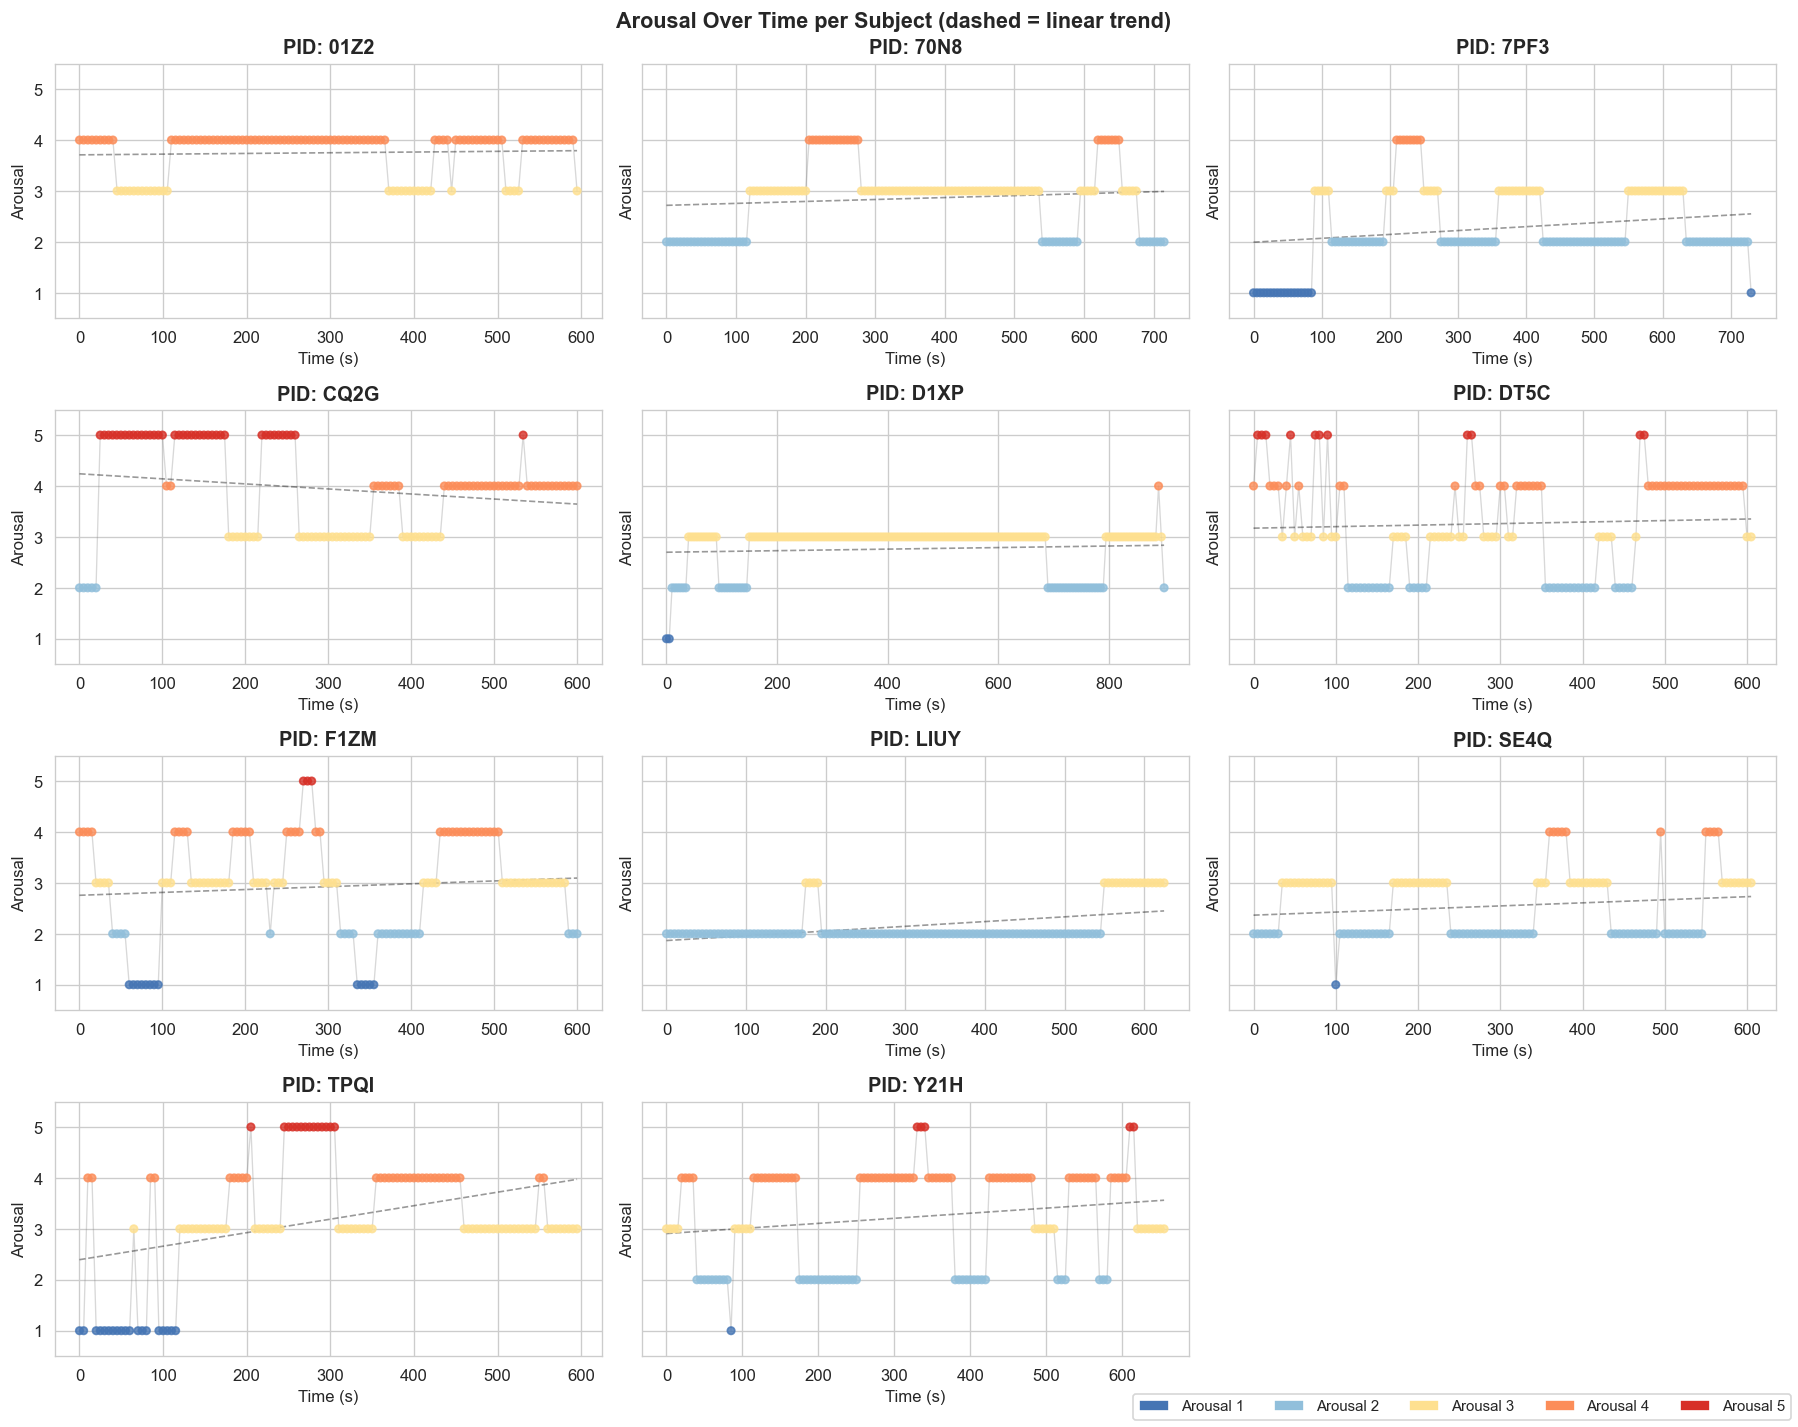

In [4]:
# ── 2-3. 시간에 따른 arousal 변화 (피험자별) ──────────────
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharey=True)
axes = axes.flatten()

for i, pid in enumerate(sorted(train_label.pid.unique())):
    grp = train_label[train_label.pid==pid].copy()
    grp['t_sec'] = (grp.timestamp - grp.timestamp.min()) / 1000
    axes[i].scatter(grp['t_sec'], grp['arousal'],
                    c=[AROUSAL_COLORS[a] for a in grp['arousal']],
                    s=20, alpha=0.8, zorder=3)
    axes[i].plot(grp['t_sec'], grp['arousal'], color='gray', alpha=0.3, linewidth=0.8)
    axes[i].set_title(f'PID: {pid}', fontweight='bold')
    axes[i].set_ylim(0.5, 5.5)
    axes[i].set_yticks([1,2,3,4,5])
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Arousal')
    # trend line
    z = np.polyfit(grp['t_sec'], grp['arousal'], 1)
    p = np.poly1d(z)
    axes[i].plot(grp['t_sec'], p(grp['t_sec']), 'k--', alpha=0.4, linewidth=1)

# hide last empty subplot
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=AROUSAL_COLORS[l], label=f'Arousal {l}') for l in [1,2,3,4,5]]
fig.legend(handles=legend_elements, loc='lower right', ncol=5, fontsize=9)

plt.suptitle('Arousal Over Time per Subject (dashed = linear trend)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. 센서별 기초 통계 & 이상치

In [5]:
# ── 3-1. 샘플링 주파수 확인 ──────────────────────────────
print('=== Sampling Frequencies ===')
freq_map = {}
for s in SENSORS:
    df = train[s].copy()
    diffs = df.groupby('pid')['timestamp'].diff().dropna()
    med_ms = diffs.median()
    hz = 1000 / med_ms
    freq_map[s] = round(hz, 1)
    print(f'  {s:8s}: {med_ms:8.2f} ms  →  {hz:6.1f} Hz')

print()
print('💡 IBI is irregularly sampled (event-driven) — needs special handling')

=== Sampling Frequencies ===
  acc     :    31.25 ms  →    32.0 Hz
  brain   :   997.00 ms  →     1.0 Hz
  bvp     :    15.63 ms  →    64.0 Hz
  eda     :   250.00 ms  →     4.0 Hz
  hr      :  1000.00 ms  →     1.0 Hz
  ibi     :   703.16 ms  →     1.4 Hz
  temp    :   250.00 ms  →     4.0 Hz

💡 IBI is irregularly sampled (event-driven) — needs special handling


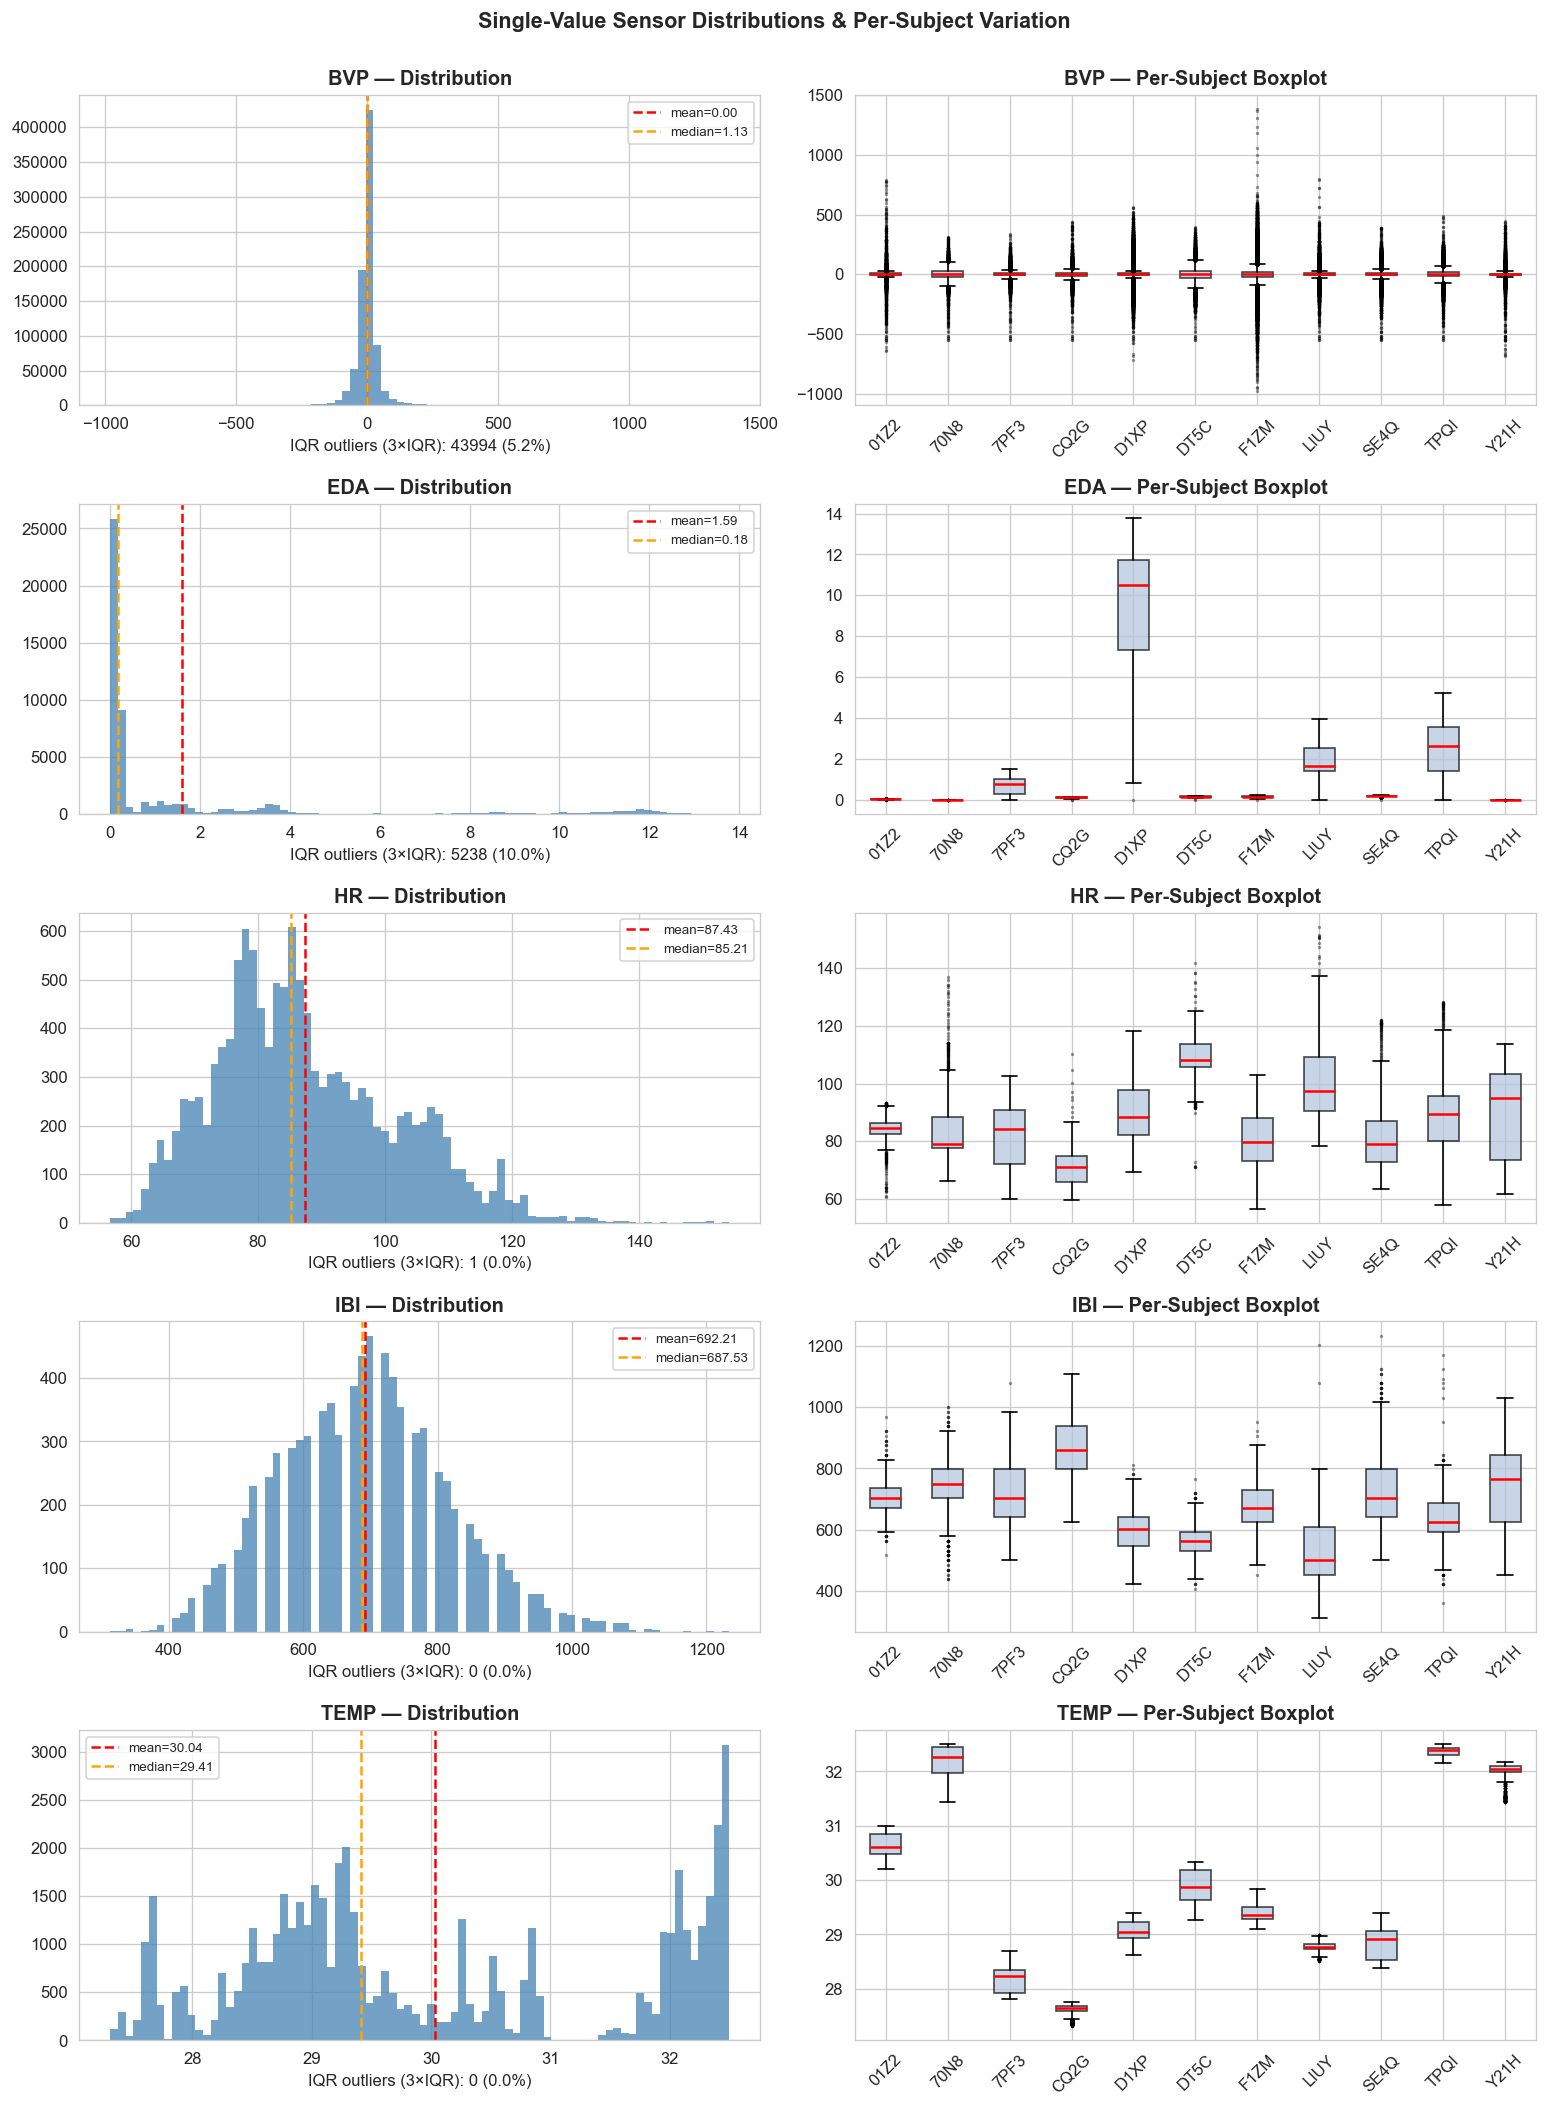

In [6]:
# ── 3-2. 센서별 분포 & 이상치 (boxplot + histogram) ──────
single_sensors = ['bvp','eda','hr','ibi','temp']

fig, axes = plt.subplots(len(single_sensors), 2, figsize=(13, 3.5*len(single_sensors)))

for i, s in enumerate(single_sensors):
    df = train[s].copy()
    vals = df['value'].dropna()

    # Histogram
    axes[i,0].hist(vals, bins=80, color='steelblue', alpha=0.75, edgecolor='none')
    axes[i,0].axvline(vals.mean(), color='red', linestyle='--', label=f'mean={vals.mean():.2f}')
    axes[i,0].axvline(vals.median(), color='orange', linestyle='--', label=f'median={vals.median():.2f}')
    axes[i,0].set_title(f'{s.upper()} — Distribution', fontweight='bold')
    axes[i,0].legend(fontsize=8)

    # Boxplot per PID
    pid_data = [df[df.pid==p]['value'].values for p in PIDS]
    bp = axes[i,1].boxplot(pid_data, labels=PIDS, patch_artist=True,
                            medianprops=dict(color='red', linewidth=1.5),
                            flierprops=dict(marker='.', markersize=2, alpha=0.4))
    for patch in bp['boxes']:
        patch.set_facecolor('lightsteelblue')
        patch.set_alpha(0.7)
    axes[i,1].set_title(f'{s.upper()} — Per-Subject Boxplot', fontweight='bold')
    axes[i,1].tick_params(axis='x', rotation=45)

    # IQR-based outlier count
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    outliers = ((vals < q1 - 3*iqr) | (vals > q3 + 3*iqr)).sum()
    axes[i,0].set_xlabel(f'IQR outliers (3×IQR): {outliers} ({outliers/len(vals)*100:.1f}%)')

plt.suptitle('Single-Value Sensor Distributions & Per-Subject Variation', fontsize=13, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

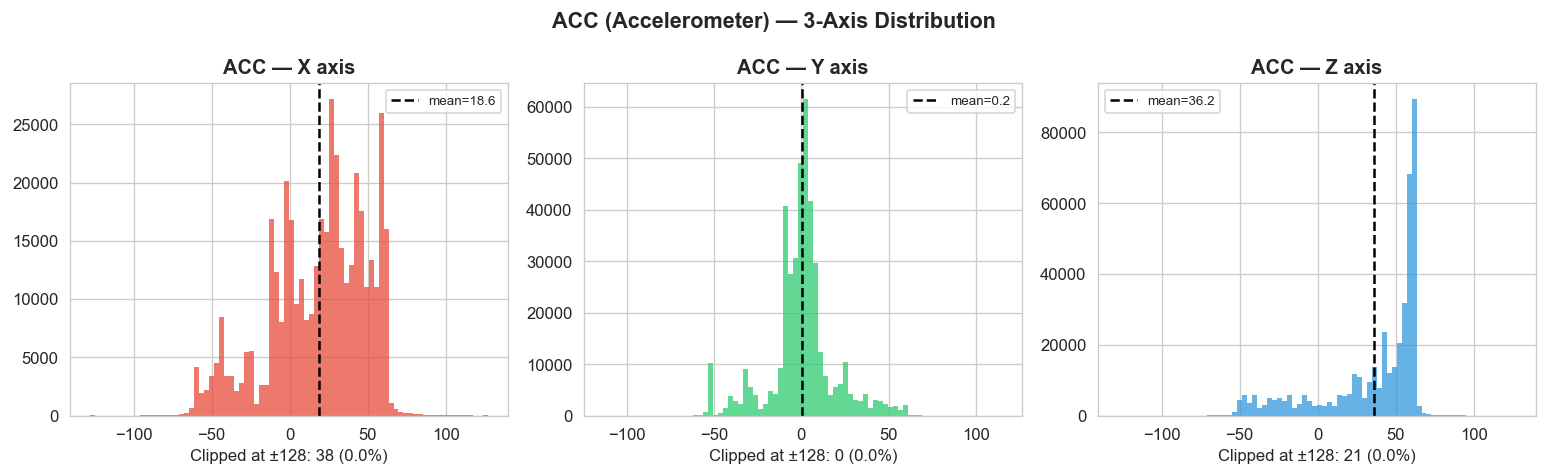

ACC magnitude stats:
count    419930.00
mean         62.98
std           3.41
min           7.68
25%          62.30
50%          62.83
75%          63.44
max         196.07
Name: magnitude, dtype: float64

Note: resting gravity ≈ 64 units (1G = 9.80665 m/s² × 64)


In [7]:
# ── 3-3. ACC 3축 분포 ──────────────────────────────────
acc = train['acc'].copy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, axis in enumerate(['x','y','z']):
    axes[i].hist(acc[axis], bins=80, color=['#e74c3c','#2ecc71','#3498db'][i],
                 alpha=0.75, edgecolor='none')
    axes[i].axvline(acc[axis].mean(), color='black', linestyle='--',
                    label=f'mean={acc[axis].mean():.1f}')
    axes[i].set_title(f'ACC — {axis.upper()} axis', fontweight='bold')
    axes[i].legend(fontsize=8)
    # mark clipping at ±128
    clipped = ((acc[axis]==-128)|(acc[axis]==127)).sum()
    axes[i].set_xlabel(f'Clipped at ±128: {clipped} ({clipped/len(acc)*100:.1f}%)')

plt.suptitle('ACC (Accelerometer) — 3-Axis Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ACC magnitude
acc['magnitude'] = np.sqrt(acc['x']**2 + acc['y']**2 + acc['z']**2)
print(f'ACC magnitude stats:\n{acc["magnitude"].describe().round(2)}')
print(f'\nNote: resting gravity ≈ 64 units (1G = 9.80665 m/s² × 64)')

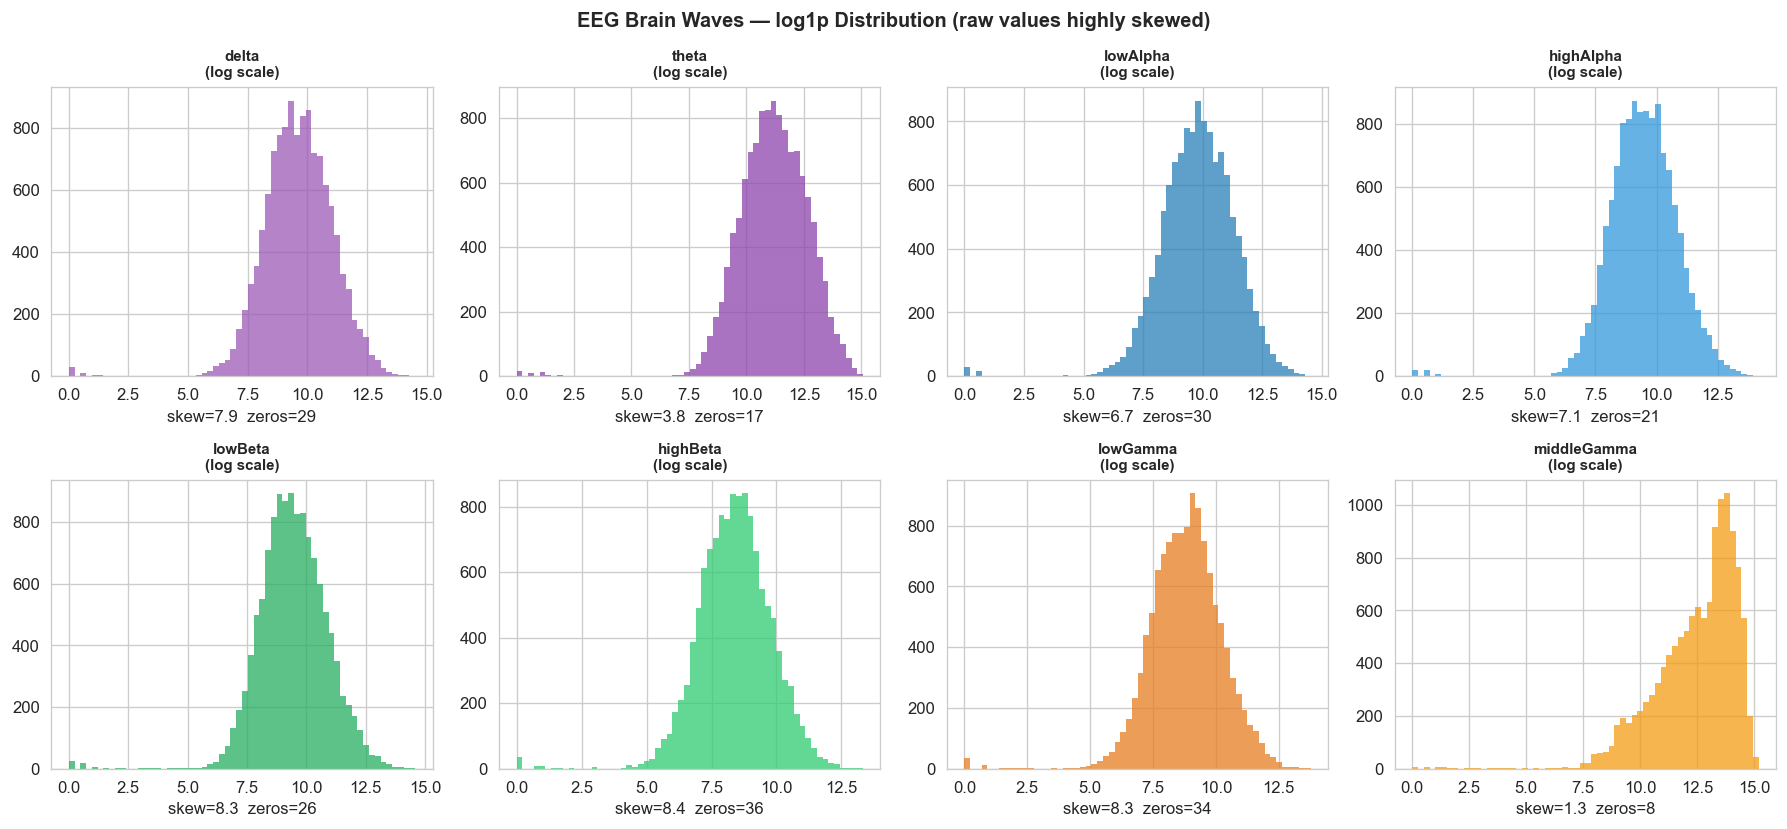

⚠ middleGamma has extremely large values — consider log transform or robust scaling
   middleGamma max: 4,038,421  |  mean: 634904


In [8]:
# ── 3-4. EEG 뇌파 분포 (Brain) ────────────────────────
brain = train['brain'].copy()
brain_cols = ['delta','theta','lowAlpha','highAlpha','lowBeta','highBeta','lowGamma','middleGamma']
brain_colors = ['#9b59b6','#8e44ad','#2980b9','#3498db','#27ae60','#2ecc71','#e67e22','#f39c12']

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(brain_cols):
    vals = brain[col]
    # log scale due to heavy skew
    log_vals = np.log1p(vals)
    axes[i].hist(log_vals, bins=60, color=brain_colors[i], alpha=0.75, edgecolor='none')
    axes[i].set_title(f'{col}\n(log scale)', fontweight='bold', fontsize=9)
    skew = stats.skew(vals)
    axes[i].set_xlabel(f'skew={skew:.1f}  zeros={( vals==0).sum()}')

plt.suptitle('EEG Brain Waves — log1p Distribution (raw values highly skewed)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('⚠ middleGamma has extremely large values — consider log transform or robust scaling')
print(f'   middleGamma max: {brain["middleGamma"].max():,}  |  mean: {brain["middleGamma"].mean():.0f}')

## 4. 결측치 & 데이터 커버리지

In [9]:
# ── 4-1. EDA zeros (sensor artifact check) ─────────────
print('=== Zero / NaN check ===')
for s in SENSORS:
    df = train[s]
    val_cols = [c for c in df.columns if c not in ['pid','timestamp']]
    for col in val_cols:
        zeros = (df[col]==0).sum()
        nans  = df[col].isna().sum()
        pct_z = zeros/len(df)*100
        if zeros > 0 or nans > 0:
            flag = '⚠' if pct_z > 5 else ''
            print(f'  {s:8s}/{col:12s}: zeros={zeros:6d} ({pct_z:5.1f}%)  NaN={nans} {flag}')

print()
print('💡 EDA zeros likely indicate sensor not in contact or signal artifact')
print('💡 BVP zeros are minimal and acceptable')

=== Zero / NaN check ===
  acc     /x           : zeros=  8411 (  2.0%)  NaN=0 
  acc     /y           : zeros= 31150 (  7.4%)  NaN=0 ⚠
  acc     /z           : zeros=   764 (  0.2%)  NaN=0 
  brain   /delta       : zeros=    29 (  0.2%)  NaN=0 
  brain   /lowAlpha    : zeros=    30 (  0.2%)  NaN=0 
  brain   /highAlpha   : zeros=    21 (  0.2%)  NaN=0 
  brain   /lowBeta     : zeros=    26 (  0.2%)  NaN=0 
  brain   /highBeta    : zeros=    36 (  0.3%)  NaN=0 
  brain   /lowGamma    : zeros=    34 (  0.3%)  NaN=0 
  brain   /middleGamma : zeros=     8 (  0.1%)  NaN=0 
  brain   /theta       : zeros=    17 (  0.1%)  NaN=0 
  bvp     /value       : zeros=   389 (  0.0%)  NaN=0 
  eda     /value       : zeros= 10717 ( 20.4%)  NaN=0 ⚠

💡 EDA zeros likely indicate sensor not in contact or signal artifact
💡 BVP zeros are minimal and acceptable


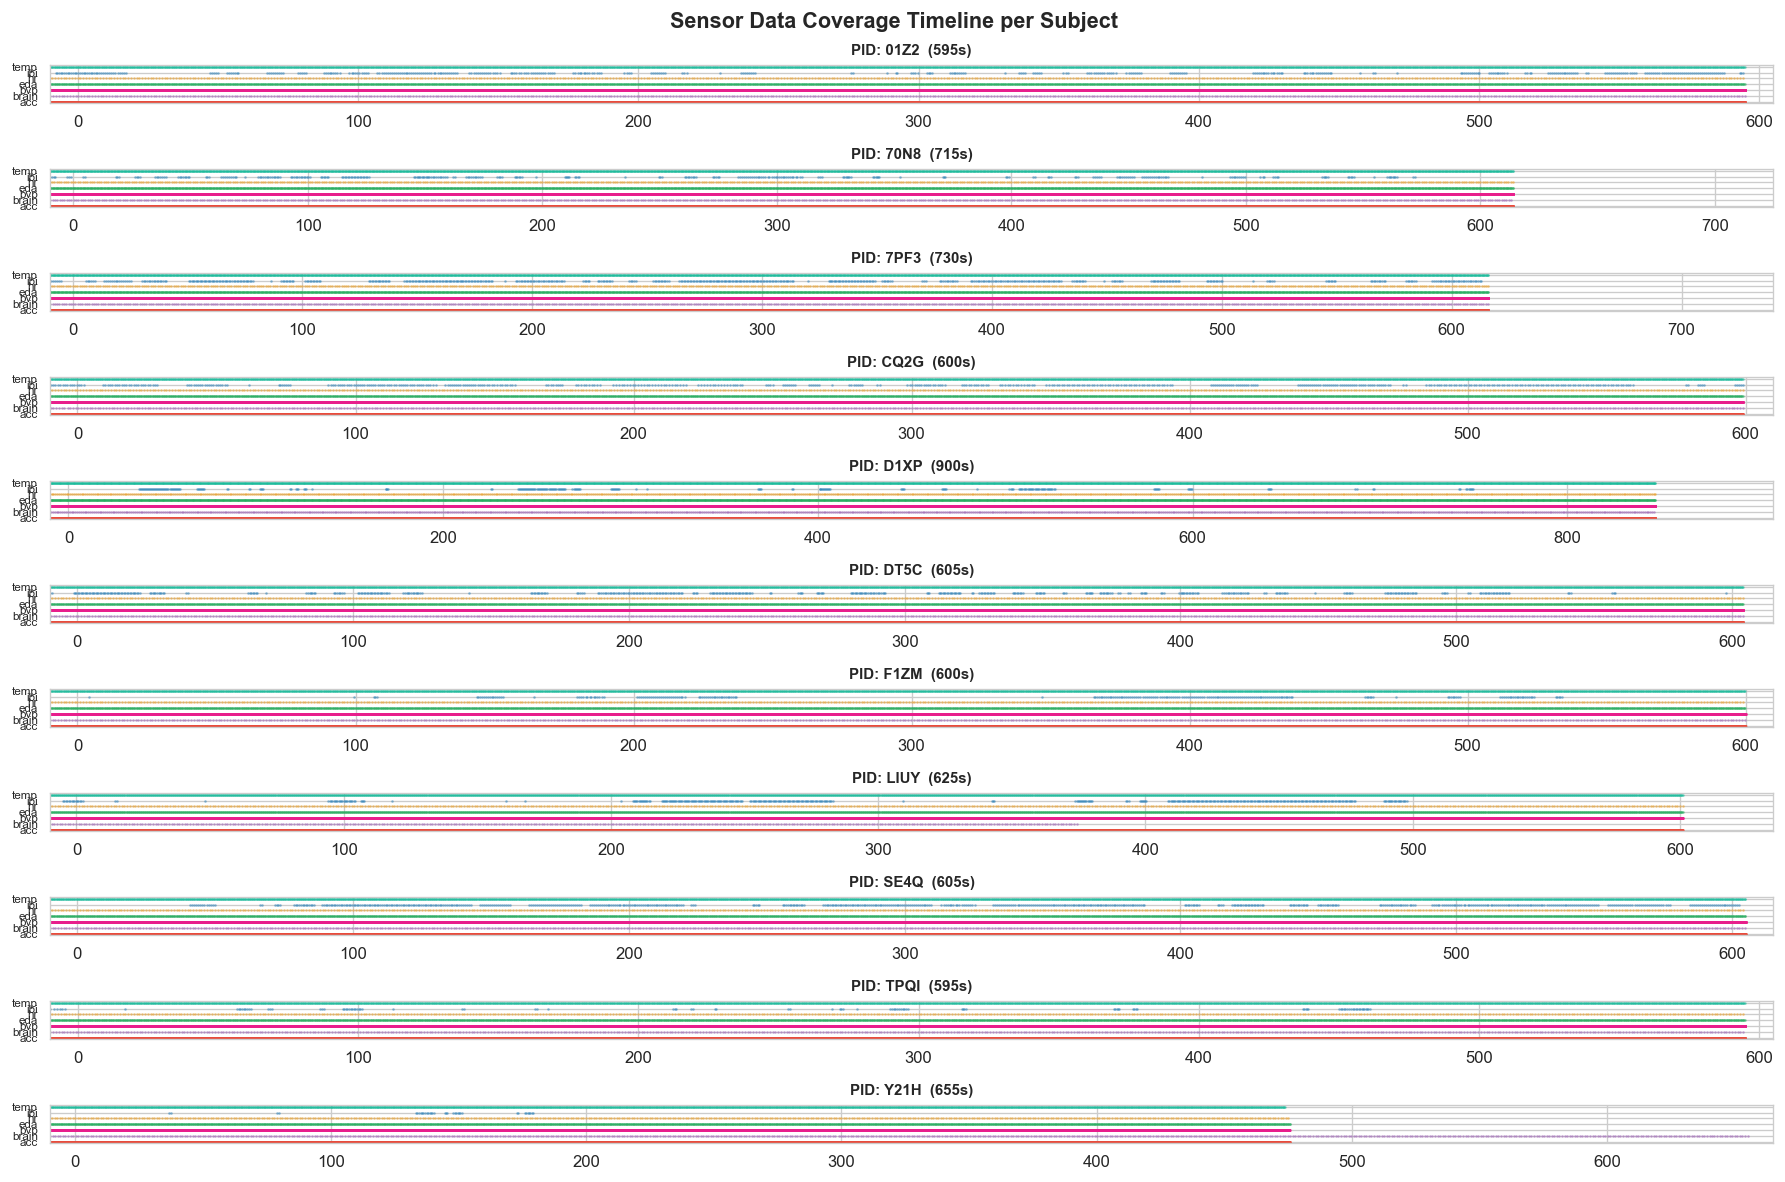

In [10]:
# ── 4-2. 센서 커버리지 시각화 (타임라인) ──────────────────
fig, axes = plt.subplots(len(PIDS), 1, figsize=(15, 10), sharex=False)

sensor_colors = {
    'acc':'#e74c3c','brain':'#9b59b6','bvp':'#e91e8c',
    'eda':'#27ae60','hr':'#f39c12','ibi':'#2980b9','temp':'#1abc9c'
}

for i, pid in enumerate(sorted(PIDS)):
    lbl = train_label[train_label.pid==pid]
    t_min = lbl.timestamp.min()
    t_max = lbl.timestamp.max()
    dur = (t_max - t_min) / 1000  # seconds

    for j, s in enumerate(SENSORS):
        df = train[s][train[s].pid==pid]
        if len(df) == 0: continue
        t = (df.timestamp - t_min) / 1000
        axes[i].scatter(t, [j]*len(t), s=0.3, color=sensor_colors[s], alpha=0.5)

    axes[i].set_yticks(range(len(SENSORS)))
    axes[i].set_yticklabels(SENSORS, fontsize=7)
    axes[i].set_title(f'PID: {pid}  ({dur:.0f}s)', fontsize=9, fontweight='bold')
    axes[i].set_xlim(-10, dur+10)

plt.suptitle('Sensor Data Coverage Timeline per Subject', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Arousal vs. 센서 신호 관계

In [11]:
# ── 5-1. 레이블 윈도우에 센서값 매핑 (±2.5초) ─────────────
def get_window_stats(sensor_df, label_df, val_col, half_win_ms=2500):
    """각 레이블 타임스탬프에서 ±half_win_ms 구간의 통계 추출"""
    records = []
    sensor_df = sensor_df.copy().sort_values(['pid','timestamp'])
    
    for _, row in label_df.iterrows():
        pid = row['pid']
        ts  = row['timestamp']
        s_pid = sensor_df[sensor_df.pid==pid]
        window = s_pid[(s_pid.timestamp >= ts - half_win_ms) &
                       (s_pid.timestamp <  ts + half_win_ms)][val_col]
        if len(window) >= 3:
            records.append({
                'id': row['id'], 'pid': pid, 'arousal': row['arousal'],
                'mean': window.mean(), 'std': window.std(),
                'min': window.min(), 'max': window.max(),
                'range': window.max()-window.min()
            })
    return pd.DataFrame(records)

print('Extracting window stats for EDA, HR, TEMP, IBI...')
ws_eda  = get_window_stats(train['eda'],  train_label, 'value')
ws_hr   = get_window_stats(train['hr'],   train_label, 'value')
ws_temp = get_window_stats(train['temp'], train_label, 'value')
ws_ibi  = get_window_stats(train['ibi'],  train_label, 'value')
print('Done!')

Extracting window stats for EDA, HR, TEMP, IBI...
Done!


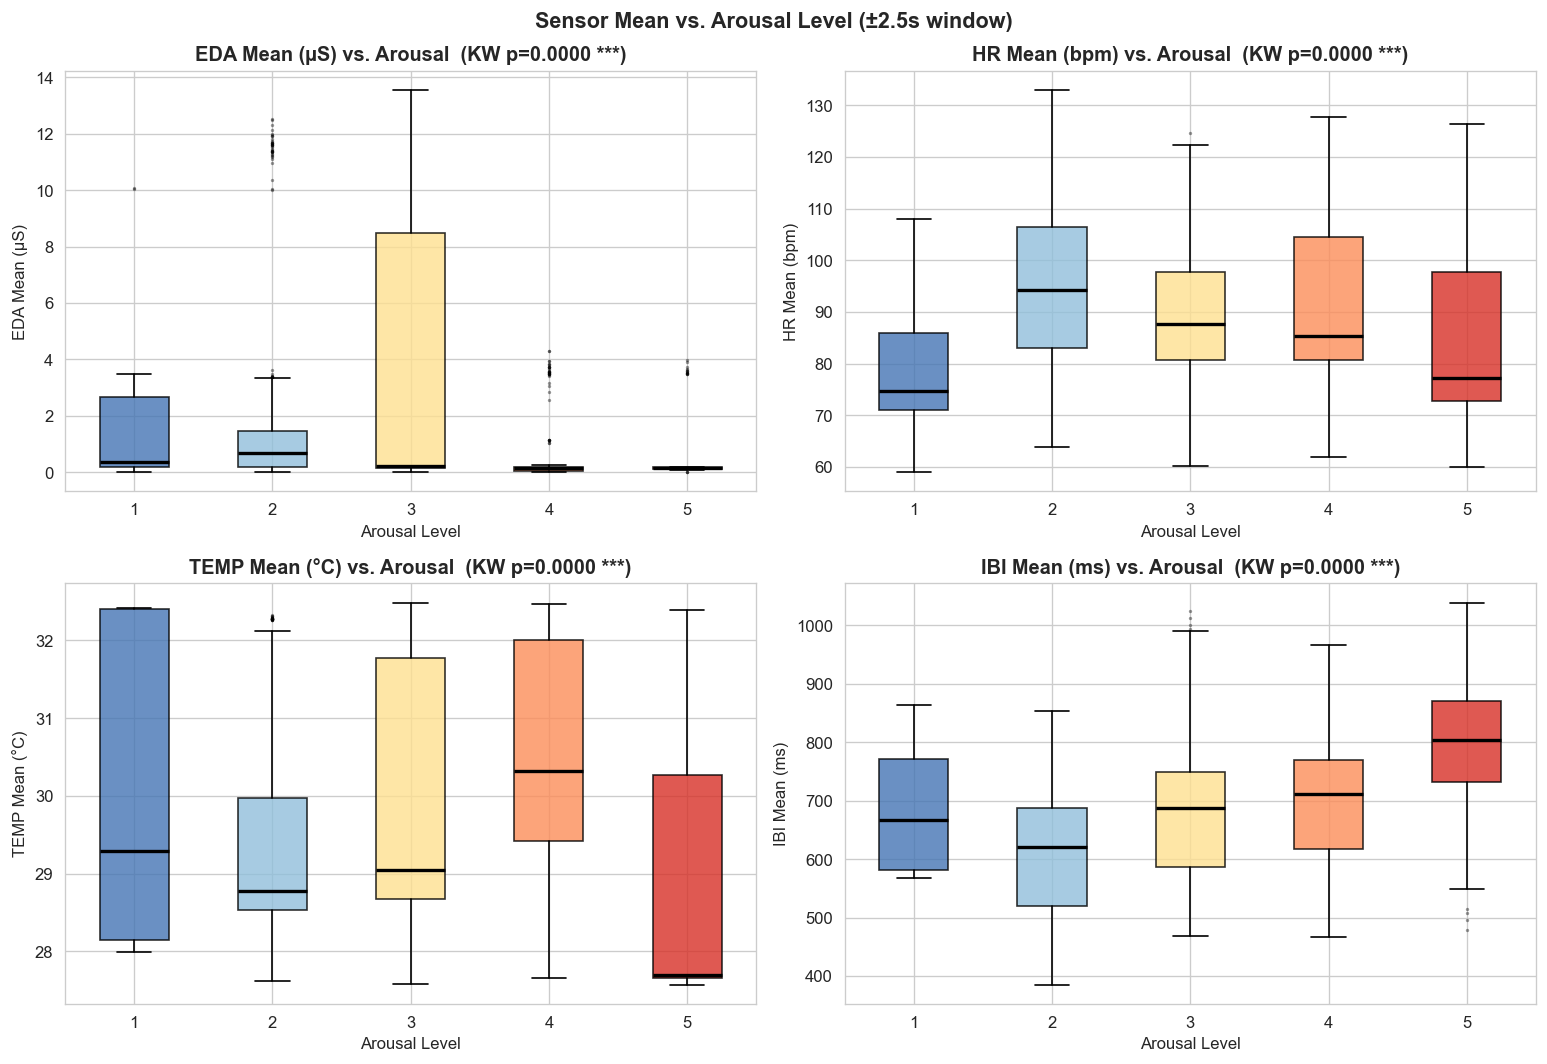

In [12]:
# ── 5-2. Arousal level별 센서 평균값 비교 ──────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
datasets = [
    (ws_eda,  'EDA Mean (µS)',      'mean', axes[0,0]),
    (ws_hr,   'HR Mean (bpm)',       'mean', axes[0,1]),
    (ws_temp, 'TEMP Mean (°C)',      'mean', axes[1,0]),
    (ws_ibi,  'IBI Mean (ms)',       'mean', axes[1,1]),
]

for df, ylabel, col, ax in datasets:
    groups = [df[df.arousal==lvl][col].dropna() for lvl in [1,2,3,4,5]]
    bp = ax.boxplot(groups, labels=[1,2,3,4,5], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.4))
    for j, patch in enumerate(bp['boxes']):
        patch.set_facecolor(list(AROUSAL_COLORS.values())[j])
        patch.set_alpha(0.8)
    ax.set_title(f'{ylabel} vs. Arousal', fontweight='bold')
    ax.set_xlabel('Arousal Level'); ax.set_ylabel(ylabel)

    # Kruskal-Wallis test
    h_stat, p_val = stats.kruskal(*[g for g in groups if len(g)>0])
    sig = '***' if p_val<0.001 else ('**' if p_val<0.01 else ('*' if p_val<0.05 else 'ns'))
    ax.set_title(f'{ylabel} vs. Arousal  (KW p={p_val:.4f} {sig})', fontweight='bold')

plt.suptitle('Sensor Mean vs. Arousal Level (±2.5s window)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

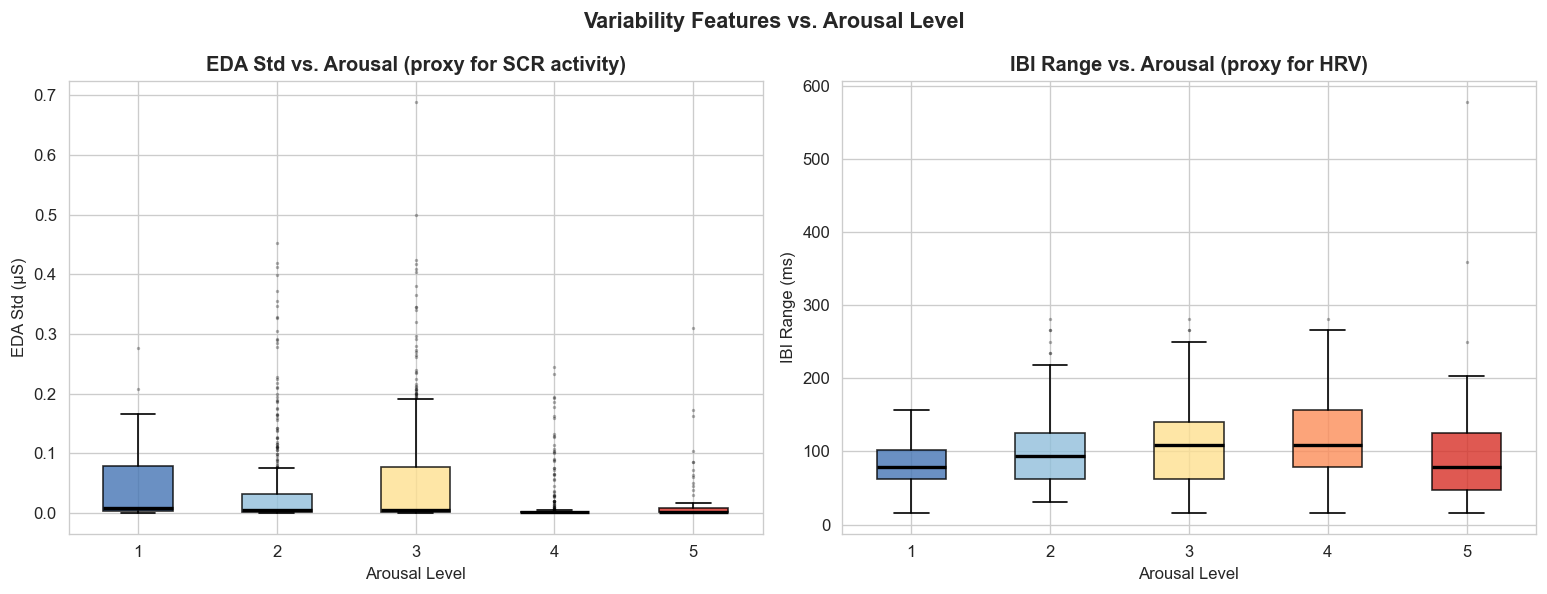

In [13]:
# ── 5-3. EDA std (SCR 대리 지표) vs Arousal ───────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# EDA std
groups_std = [ws_eda[ws_eda.arousal==lvl]['std'].dropna() for lvl in [1,2,3,4,5]]
bp = axes[0].boxplot(groups_std, labels=[1,2,3,4,5], patch_artist=True,
                      medianprops=dict(color='black', linewidth=2),
                      flierprops=dict(marker='.', markersize=2, alpha=0.3))
for j, patch in enumerate(bp['boxes']):
    patch.set_facecolor(list(AROUSAL_COLORS.values())[j]); patch.set_alpha(0.8)
axes[0].set_title('EDA Std vs. Arousal (proxy for SCR activity)', fontweight='bold')
axes[0].set_xlabel('Arousal Level'); axes[0].set_ylabel('EDA Std (µS)')

# IBI range (HRV proxy)
groups_rng = [ws_ibi[ws_ibi.arousal==lvl]['range'].dropna() for lvl in [1,2,3,4,5]]
bp2 = axes[1].boxplot(groups_rng, labels=[1,2,3,4,5], patch_artist=True,
                       medianprops=dict(color='black', linewidth=2),
                       flierprops=dict(marker='.', markersize=2, alpha=0.3))
for j, patch in enumerate(bp2['boxes']):
    patch.set_facecolor(list(AROUSAL_COLORS.values())[j]); patch.set_alpha(0.8)
axes[1].set_title('IBI Range vs. Arousal (proxy for HRV)', fontweight='bold')
axes[1].set_xlabel('Arousal Level'); axes[1].set_ylabel('IBI Range (ms)')

plt.suptitle('Variability Features vs. Arousal Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Extracting EEG window stats...
Done! 1352 records


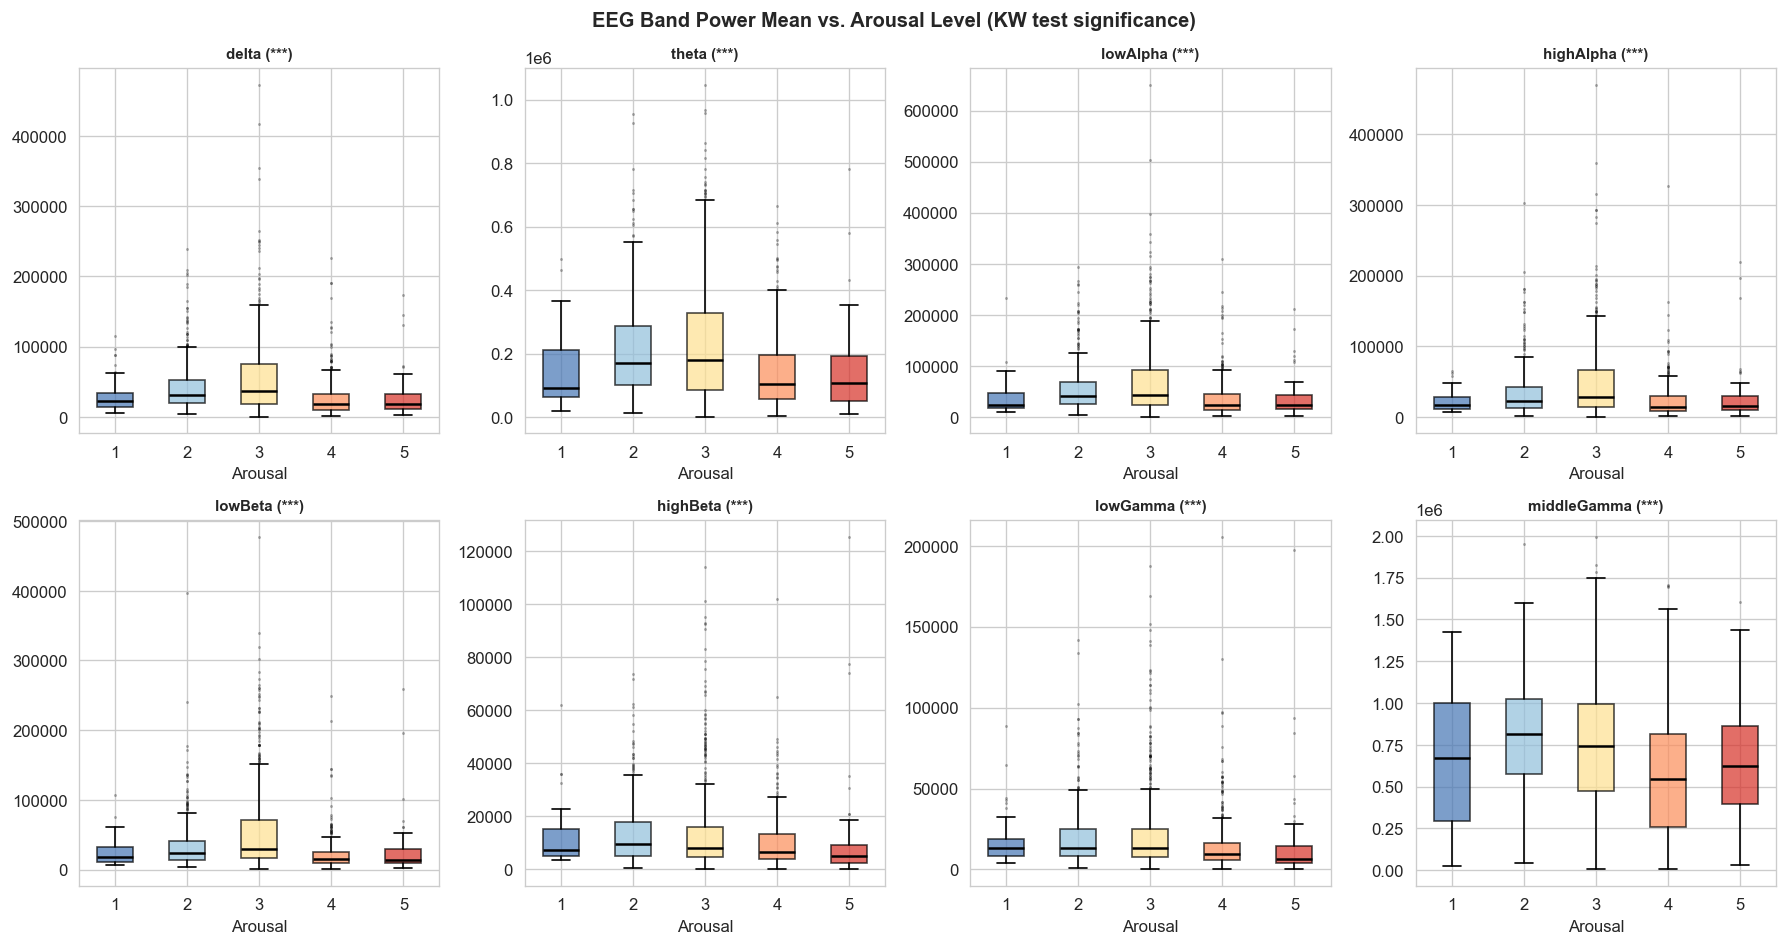

In [14]:
# ── 5-4. EEG band power vs Arousal ────────────────────
def get_eeg_window_stats(label_df, half_win_ms=2500):
    brain_df = train['brain'].copy().sort_values(['pid','timestamp'])
    eeg_cols = ['delta','theta','lowAlpha','highAlpha','lowBeta','highBeta','lowGamma','middleGamma']
    records = []
    for _, row in label_df.iterrows():
        pid, ts = row['pid'], row['timestamp']
        s = brain_df[brain_df.pid==pid]
        win = s[(s.timestamp >= ts-half_win_ms) & (s.timestamp < ts+half_win_ms)]
        if len(win) >= 1:
            rec = {'arousal': row['arousal']}
            for col in eeg_cols:
                rec[col+'_mean'] = win[col].mean()
            records.append(rec)
    return pd.DataFrame(records)

print('Extracting EEG window stats...')
ws_eeg = get_eeg_window_stats(train_label)
print(f'Done! {len(ws_eeg)} records')

# Plot
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()
eeg_cols = ['delta','theta','lowAlpha','highAlpha','lowBeta','highBeta','lowGamma','middleGamma']

for i, col in enumerate(eeg_cols):
    groups = [ws_eeg[ws_eeg.arousal==lvl][col+'_mean'].dropna() for lvl in [1,2,3,4,5]]
    bp = axes[i].boxplot(groups, labels=[1,2,3,4,5], patch_artist=True,
                          medianprops=dict(color='black', linewidth=1.5),
                          flierprops=dict(marker='.', markersize=1.5, alpha=0.3))
    for j, patch in enumerate(bp['boxes']):
        patch.set_facecolor(list(AROUSAL_COLORS.values())[j]); patch.set_alpha(0.7)
    h, p = stats.kruskal(*[g for g in groups if len(g)>0])
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    axes[i].set_title(f'{col} ({sig})', fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Arousal')

plt.suptitle('EEG Band Power Mean vs. Arousal Level (KW test significance)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. 피험자 간 변동성 (개인차)

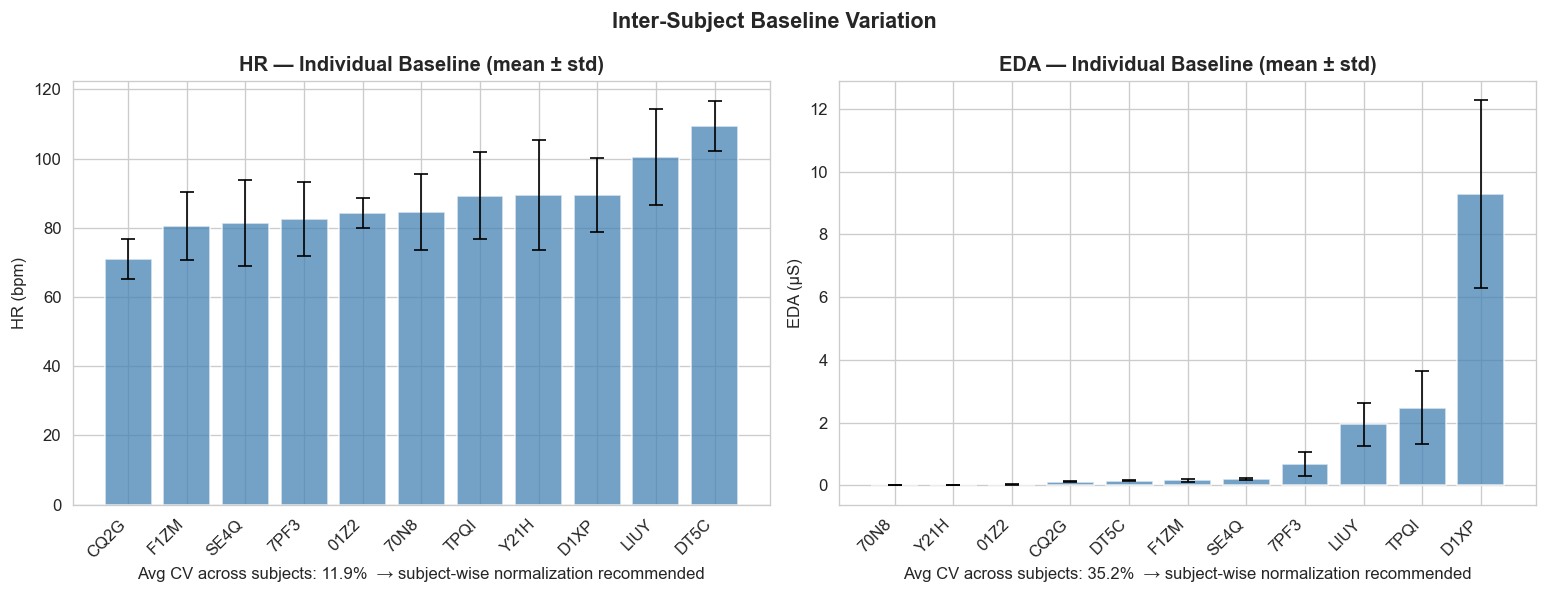

In [15]:
# ── 6-1. 피험자별 HR/EDA 기준선 차이 ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (s, col, unit) in zip(axes, [('hr','value','bpm'), ('eda','value','µS')]):
    df = train[s]
    pid_means = df.groupby('pid')[col].mean().sort_values()
    pid_stds  = df.groupby('pid')[col].std()
    
    bars = ax.bar(range(len(pid_means)), pid_means.values,
                  yerr=pid_stds[pid_means.index].values,
                  color='steelblue', alpha=0.75, capsize=4, error_kw={'linewidth':1})
    ax.set_xticks(range(len(pid_means)))
    ax.set_xticklabels(pid_means.index, rotation=45, ha='right')
    ax.set_title(f'{s.upper()} — Individual Baseline (mean ± std)', fontweight='bold')
    ax.set_ylabel(f'{s.upper()} ({unit})')

    # CV (coefficient of variation)
    cv = pid_stds.mean() / pid_means.mean() * 100
    ax.set_xlabel(f'Avg CV across subjects: {cv:.1f}%  → subject-wise normalization recommended')

plt.suptitle('Inter-Subject Baseline Variation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

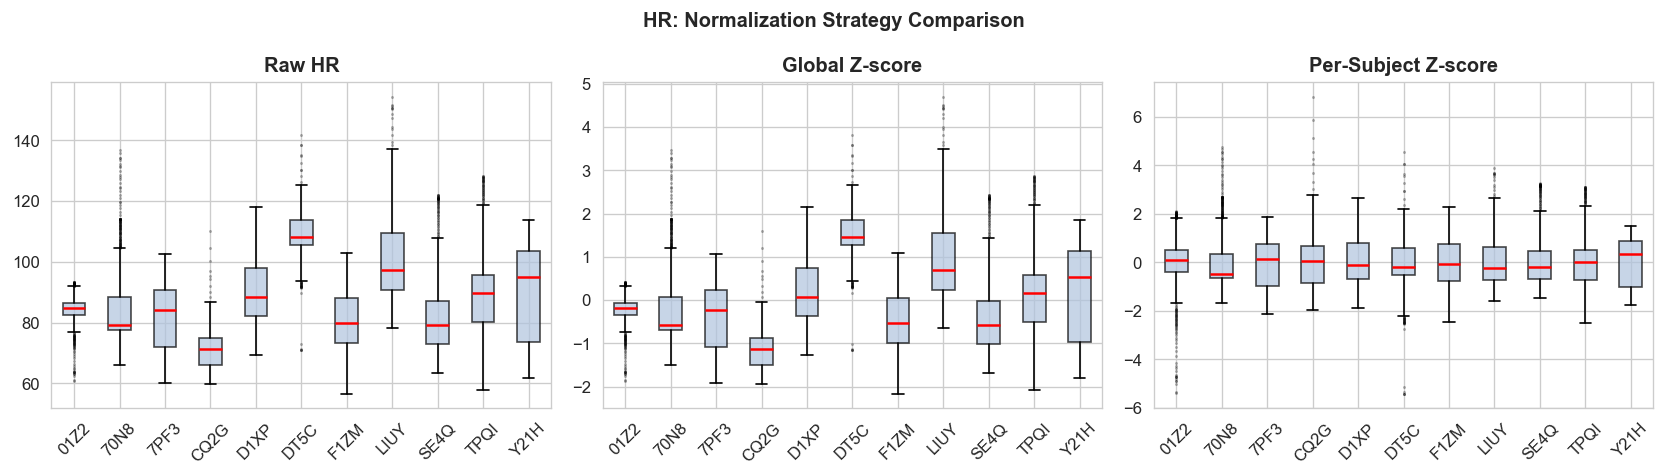

✅ Per-subject z-score aligns medians → recommended for physiological signals


In [16]:
# ── 6-2. 피험자 내 정규화 효과 비교 ─────────────────────
hr = train['hr'].copy()

# Global z-score
hr['z_global'] = (hr['value'] - hr['value'].mean()) / hr['value'].std()
# Per-subject z-score
hr['z_subject'] = hr.groupby('pid')['value'].transform(lambda x: (x-x.mean())/x.std())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes,
    ['value','z_global','z_subject'],
    ['Raw HR','Global Z-score','Per-Subject Z-score']):
    pid_data = [hr[hr.pid==p][col].values for p in PIDS]
    bp = ax.boxplot(pid_data, labels=PIDS, patch_artist=True,
                    medianprops=dict(color='red', linewidth=1.5),
                    flierprops=dict(marker='.', markersize=1.5, alpha=0.3))
    for patch in bp['boxes']:
        patch.set_facecolor('lightsteelblue'); patch.set_alpha(0.7)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('HR: Normalization Strategy Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Per-subject z-score aligns medians → recommended for physiological signals')

## 7. 시계열 원시 신호 시각화

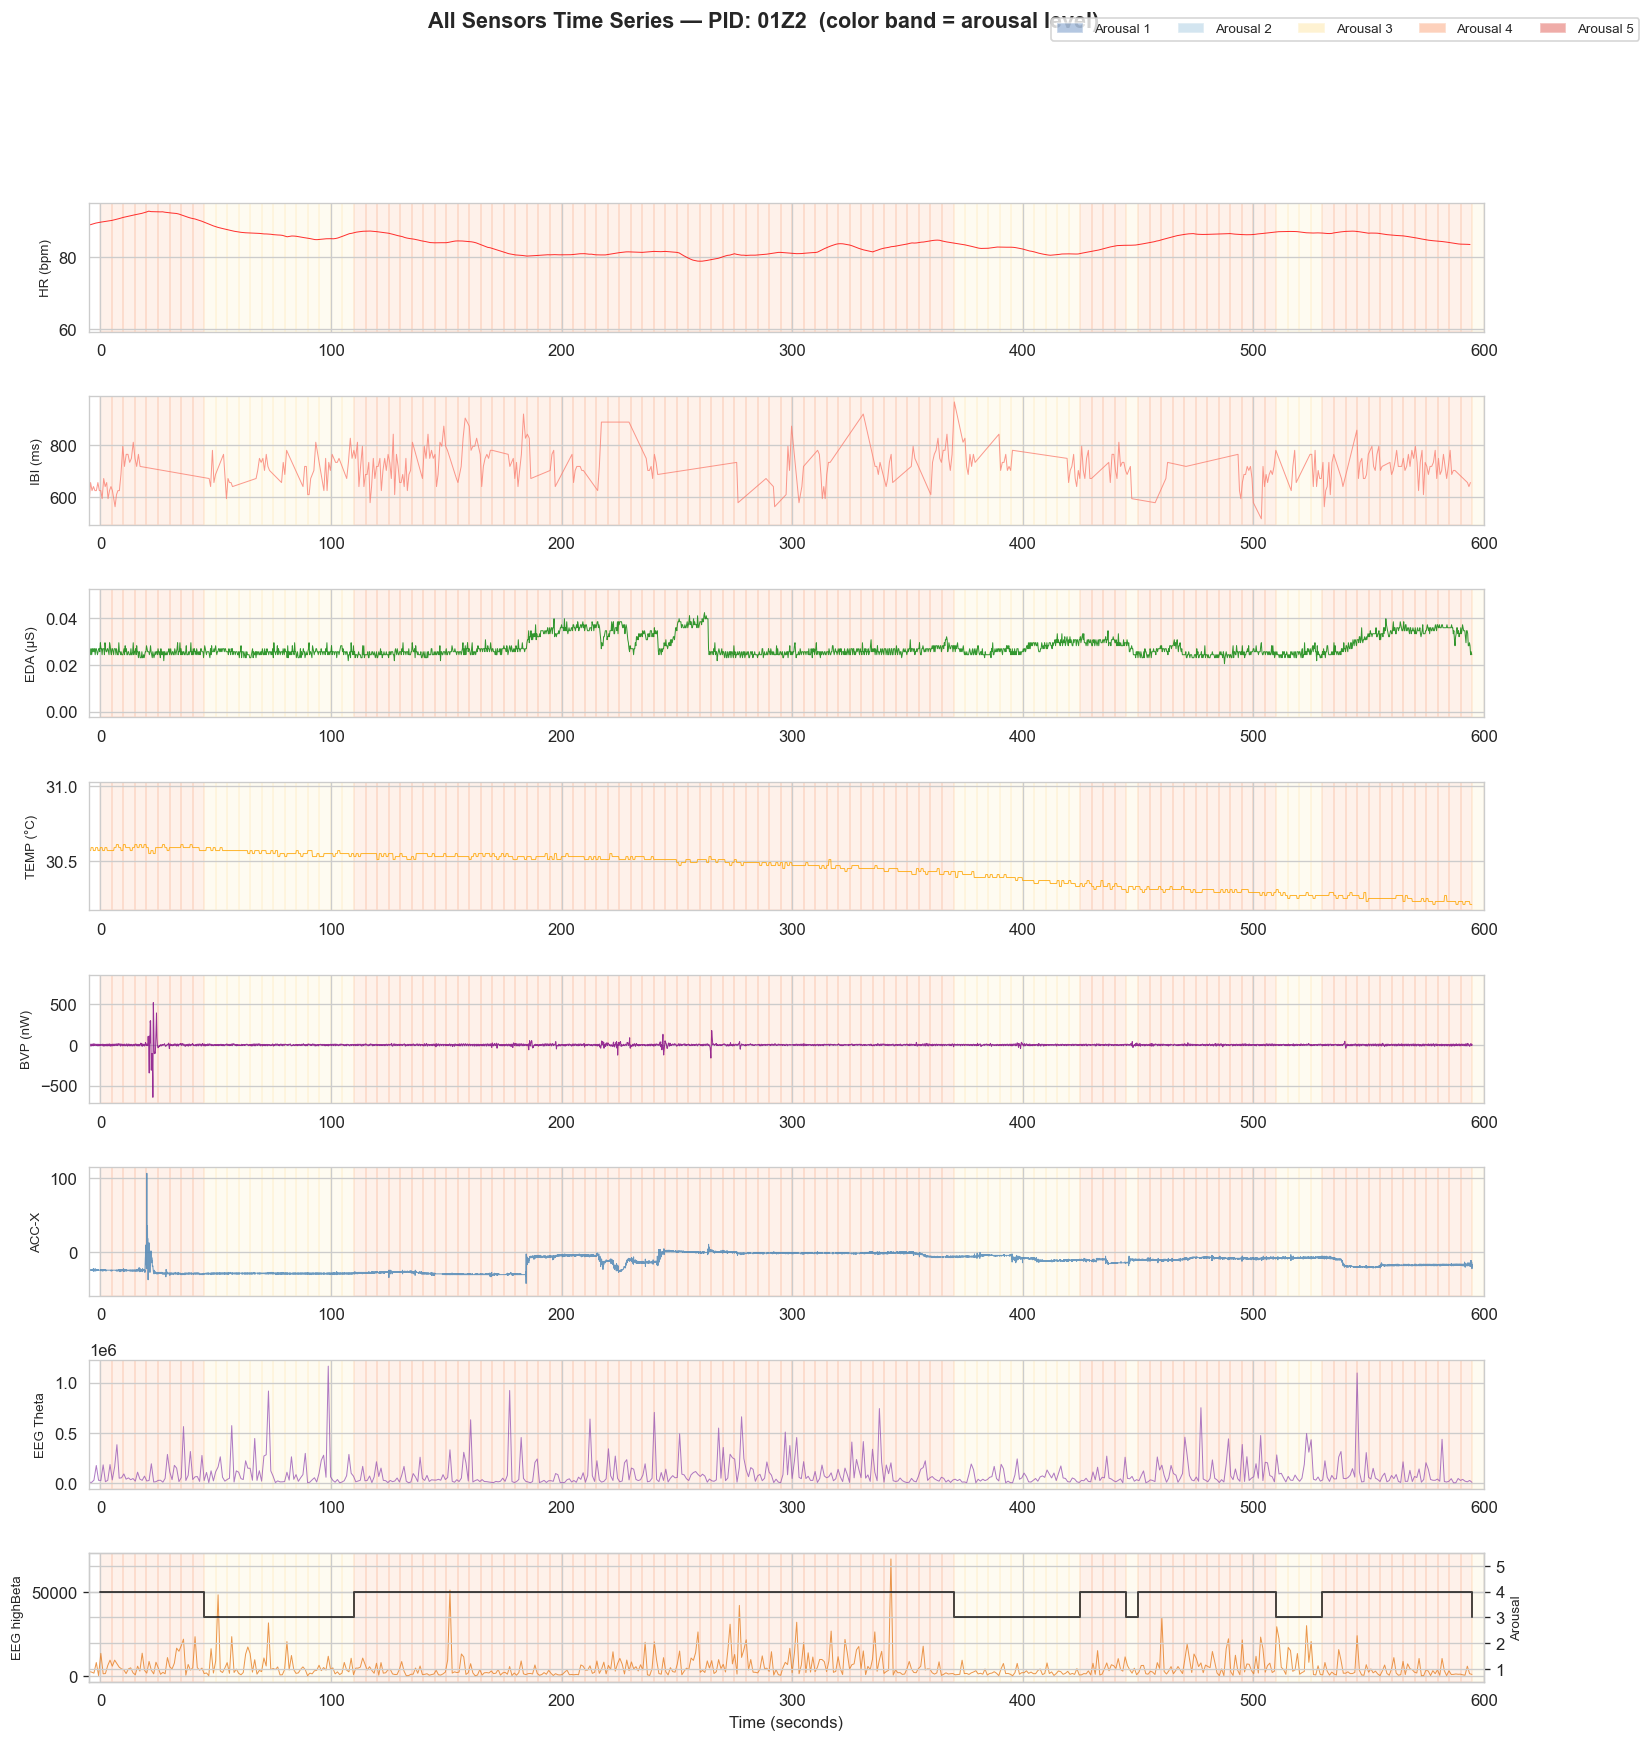

In [17]:
# ── 7-1. 한 피험자의 모든 센서 시계열 ─────────────────
TARGET_PID = '01Z2'  # 바꿔서 다른 피험자 확인 가능

lbl_pid = train_label[train_label.pid==TARGET_PID].copy()
lbl_pid['t'] = (lbl_pid.timestamp - lbl_pid.timestamp.min()) / 1000

fig = plt.figure(figsize=(15, 16))
gs  = gridspec.GridSpec(8, 1, hspace=0.5)

plot_cfg = [
    ('hr',    'value', 'HR (bpm)',      'red'),
    ('ibi',   'value', 'IBI (ms)',      'salmon'),
    ('eda',   'value', 'EDA (µS)',      'green'),
    ('temp',  'value', 'TEMP (°C)',     'orange'),
    ('bvp',   'value', 'BVP (nW)',      'purple'),
    ('acc',   'x',     'ACC-X',         'steelblue'),
    ('brain', 'theta', 'EEG Theta',     '#9b59b6'),
    ('brain', 'highBeta', 'EEG highBeta', '#e67e22'),
]

for i, (s, col, ylabel, color) in enumerate(plot_cfg):
    ax = fig.add_subplot(gs[i])
    df = train[s][train[s].pid==TARGET_PID].copy()
    df['t'] = (df.timestamp - lbl_pid.timestamp.min()) / 1000
    ax.plot(df['t'], df[col], color=color, linewidth=0.6, alpha=0.8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xlim(lbl_pid['t'].min()-5, lbl_pid['t'].max()+5)

    # arousal color bands
    for _, r in lbl_pid.iterrows():
        ax.axvspan(r['t'], r['t']+5, alpha=0.12,
                   color=AROUSAL_COLORS[r['arousal']], zorder=0)

axes_list = [fig.axes[j] for j in range(len(plot_cfg))]
axes_list[-1].set_xlabel('Time (seconds)')

# Arousal overlay on last subplot
ax_a = axes_list[-1].twinx()
ax_a.step(lbl_pid['t'], lbl_pid['arousal'], color='black',
          linewidth=1.2, where='post', alpha=0.7)
ax_a.set_ylim(0.5, 5.5); ax_a.set_yticks([1,2,3,4,5])
ax_a.set_ylabel('Arousal', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=AROUSAL_COLORS[l], alpha=0.4, label=f'Arousal {l}') for l in [1,2,3,4,5]]
fig.legend(handles=legend_elements, loc='upper right', ncol=5, fontsize=8, bbox_to_anchor=(0.99, 0.98))

plt.suptitle(f'All Sensors Time Series — PID: {TARGET_PID}  (color band = arousal level)',
             fontsize=13, fontweight='bold')
plt.show()

## 8. 특징 중요도 미리보기 (Feature Importance Preview)

In [18]:
# ── 8-1. 간단한 통계 특징 추출 후 Random Forest 중요도 ──
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

def build_simple_features(label_df, half_win_ms=2500):
    """빠른 특징 추출 (EDA, HR, TEMP, IBI, Brain)"""
    records = []
    for _, row in label_df.iterrows():
        pid, ts = row['pid'], row['timestamp']
        feat = {'id': row.get('id', 0), 'pid': pid, 'arousal': row['arousal']}

        for s in ['eda','hr','temp','ibi']:
            df = train[s][train[s].pid==pid]
            win = df[(df.timestamp>=ts-half_win_ms)&(df.timestamp<ts+half_win_ms)]['value']
            if len(win) >= 2:
                feat[f'{s}_mean'] = win.mean()
                feat[f'{s}_std']  = win.std()
                feat[f'{s}_range']= win.max()-win.min()
            else:
                feat[f'{s}_mean'] = np.nan
                feat[f'{s}_std']  = np.nan
                feat[f'{s}_range']= np.nan

        # EEG
        eeg_df = train['brain'][train['brain'].pid==pid]
        win_e = eeg_df[(eeg_df.timestamp>=ts-half_win_ms)&(eeg_df.timestamp<ts+half_win_ms)]
        for col in ['delta','theta','lowAlpha','highBeta','middleGamma']:
            feat[f'eeg_{col}'] = np.log1p(win_e[col].mean()) if len(win_e)>=1 else np.nan

        # ACC magnitude std
        acc_df = train['acc'][train['acc'].pid==pid]
        win_a = acc_df[(acc_df.timestamp>=ts-half_win_ms)&(acc_df.timestamp<ts+half_win_ms)]
        if len(win_a) >= 5:
            mag = np.sqrt(win_a['x']**2+win_a['y']**2+win_a['z']**2)
            feat['acc_mag_mean'] = mag.mean()
            feat['acc_mag_std']  = mag.std()
        else:
            feat['acc_mag_mean'] = np.nan
            feat['acc_mag_std']  = np.nan

        records.append(feat)
    return pd.DataFrame(records)

print('Building features (may take ~30s)...')
feat_df = build_simple_features(train_label)
print(f'Feature matrix: {feat_df.shape}')
print(feat_df.isnull().sum().sort_values(ascending=False).head(10))

Building features (may take ~30s)...
Feature matrix: (1456, 22)
ibi_mean           812
ibi_range          812
ibi_std            812
eeg_middleGamma    104
eeg_highBeta       104
eeg_lowAlpha       104
eeg_theta          104
eeg_delta          104
temp_range          95
acc_mag_mean        95
dtype: int64


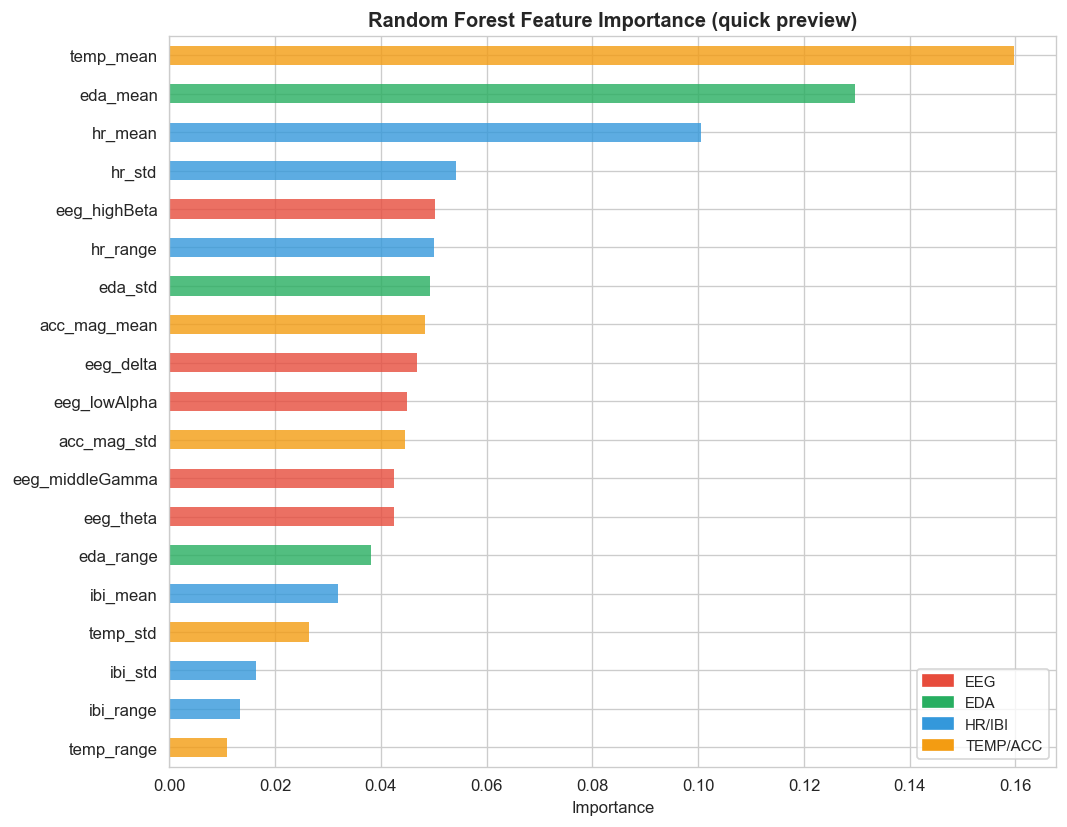


Top 5 features:
  temp_mean                : 0.1597
  eda_mean                 : 0.1296
  hr_mean                  : 0.1006
  hr_std                   : 0.0542
  eeg_highBeta             : 0.0502


In [19]:
# ── 8-2. RF 특징 중요도 ──────────────────────────────
feat_cols = [c for c in feat_df.columns if c not in ['id','pid','arousal']]
X = feat_df[feat_cols].fillna(feat_df[feat_cols].median())
y = feat_df['arousal']

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if 'eeg' in f else ('#27ae60' if 'eda' in f else
          ('#3498db' if 'hr' in f or 'ibi' in f else '#f39c12'))
          for f in importances.index]
importances.plot(kind='barh', ax=ax, color=colors, alpha=0.8, edgecolor='none')
ax.set_title('Random Forest Feature Importance (quick preview)', fontweight='bold')
ax.set_xlabel('Importance')

from matplotlib.patches import Patch
legend = [
    Patch(color='#e74c3c', label='EEG'),
    Patch(color='#27ae60', label='EDA'),
    Patch(color='#3498db', label='HR/IBI'),
    Patch(color='#f39c12', label='TEMP/ACC'),
]
ax.legend(handles=legend, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f'  {feat:25s}: {imp:.4f}')

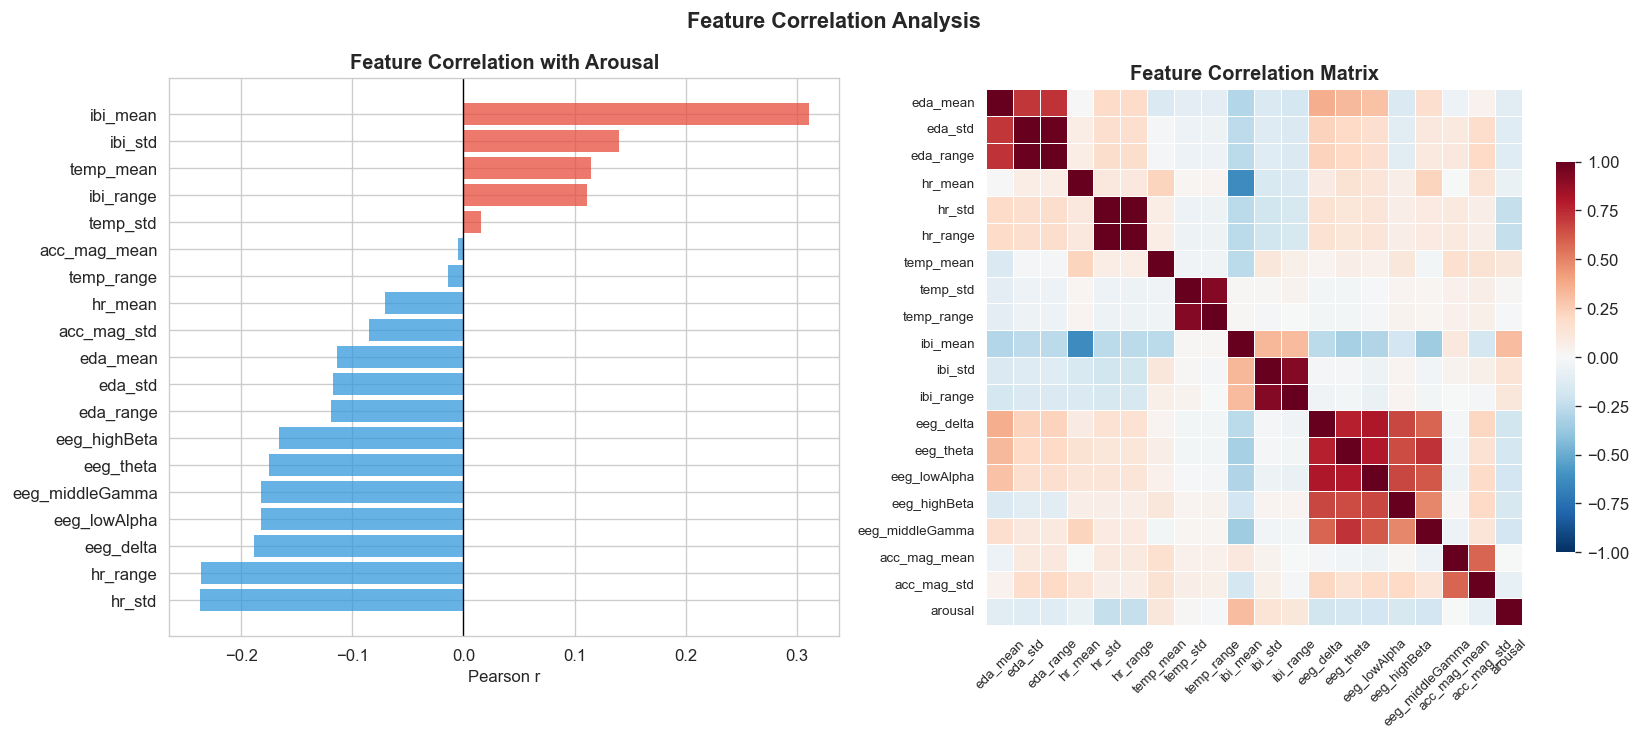

In [20]:
# ── 8-3. 특징 간 상관관계 ─────────────────────────────
corr = feat_df[feat_cols + ['arousal']].corr()

# arousal과의 상관만
arousal_corr = corr['arousal'].drop('arousal').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# bar plot of correlations with arousal
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in arousal_corr.values]
axes[0].barh(arousal_corr.index, arousal_corr.values, color=colors_bar, alpha=0.75, edgecolor='none')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with Arousal', fontweight='bold')
axes[0].set_xlabel('Pearson r')

# heatmap
sns.heatmap(corr, ax=axes[1], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0.3,
            cbar_kws={'shrink': 0.7})
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Feature Correlation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. EDA 요약 — 주요 발견 사항

In [21]:
print('=' * 65)
print('  EDA SUMMARY — KEY FINDINGS')
print('=' * 65)

findings = [
    ('LABEL', [
        '클래스 불균형: Arousal 3 > 2 > 4 > 1 > 5  (비율 최대 7.7x)',
        '피험자마다 선호 arousal 범위가 크게 다름 → LOSO CV 필수',
        '5초 간격 레이블, 세션 10~15분/피험자',
    ]),
    ('SENSOR FREQ', [
        'ACC:32Hz  BVP:64Hz  EDA/TEMP:4Hz  HR/Brain:1Hz  IBI:불규칙',
        '→ 공통 주파수(4Hz)로 리샘플링 후 정렬 필요',
    ]),
    ('OUTLIERS / ARTIFACTS', [
        'EDA zeros: 20.4% → 센서 미접촉 구간, 별도 플래그 처리',
        'ACC ±128 클리핑 존재 → 움직임 포화 구간',
        'BVP 범위 매우 넓음(-981 ~ 1384) → Robust Scaler 적용',
        'EEG middleGamma 극단값 존재 → log1p 변환 필수',
    ]),
    ('INDIVIDUAL DIFF', [
        'HR 기준선: 피험자별 최대 30bpm 차이',
        'EDA 기준선: 0에 가까운 피험자 vs 10µS 피험자 공존',
        '→ Per-subject z-score normalization 강력 권장',
    ]),
    ('USEFUL FEATURES (top)', [
        'EDA mean/std — SCR 활동 지표, arousal과 유의미한 상관',
        'HR mean — 심박수 상승이 고각성과 관련',
        'IBI range — HRV 대리 지표',
        'EEG theta/highBeta — 인지 부하 및 각성 관련',
        'TEMP mean — 말초 혈류 반영 (역상관 가능)',
    ]),
    ('NEXT STEPS', [
        '1. 리샘플링 + per-subject z-score 정규화',
        '2. EDA zeros 구간 마스킹 or 보간',
        '3. Sliding window (5s, stride 1–2.5s) 적용',
        '4. 도메인 특징 추출 (HRV, SCR, EEG ratios)',
        '5. SMOTE + class_weight 조합으로 불균형 처리',
    ]),
]

for section, items in findings:
    print(f'\n[{section}]')
    for item in items:
        print(f'  • {item}')

print('\n' + '=' * 65)

  EDA SUMMARY — KEY FINDINGS

[LABEL]
  • 클래스 불균형: Arousal 3 > 2 > 4 > 1 > 5  (비율 최대 7.7x)
  • 피험자마다 선호 arousal 범위가 크게 다름 → LOSO CV 필수
  • 5초 간격 레이블, 세션 10~15분/피험자

[SENSOR FREQ]
  • ACC:32Hz  BVP:64Hz  EDA/TEMP:4Hz  HR/Brain:1Hz  IBI:불규칙
  • → 공통 주파수(4Hz)로 리샘플링 후 정렬 필요

[OUTLIERS / ARTIFACTS]
  • EDA zeros: 20.4% → 센서 미접촉 구간, 별도 플래그 처리
  • ACC ±128 클리핑 존재 → 움직임 포화 구간
  • BVP 범위 매우 넓음(-981 ~ 1384) → Robust Scaler 적용
  • EEG middleGamma 극단값 존재 → log1p 변환 필수

[INDIVIDUAL DIFF]
  • HR 기준선: 피험자별 최대 30bpm 차이
  • EDA 기준선: 0에 가까운 피험자 vs 10µS 피험자 공존
  • → Per-subject z-score normalization 강력 권장

[USEFUL FEATURES (top)]
  • EDA mean/std — SCR 활동 지표, arousal과 유의미한 상관
  • HR mean — 심박수 상승이 고각성과 관련
  • IBI range — HRV 대리 지표
  • EEG theta/highBeta — 인지 부하 및 각성 관련
  • TEMP mean — 말초 혈류 반영 (역상관 가능)

[NEXT STEPS]
  • 1. 리샘플링 + per-subject z-score 정규화
  • 2. EDA zeros 구간 마스킹 or 보간
  • 3. Sliding window (5s, stride 1–2.5s) 적용
  • 4. 도메인 특징 추출 (HRV, SCR, EEG ratios)
  • 5. SMOTE + class_weight 조합으로 불균형 처